### fitting Ks mag, Teff, Fe/H, and parallax

In [1]:
from jaxstar import mistfit
from jax import random
import arviz, corner
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpyro_inferutils.experimental import MultiNestRunner

/Users/k_masuda/miniforge3/envs/multinest-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mf = mistfit.MistFit()

In [3]:
# observed Kmag, Teff, Fe/H, parallax (mas)
kmag_obs, kmag_err, teff_obs, feh_obs, parallax_obs, parallax_err\
= [ 8.84300000e+00,  1.40000000e-02,  5.71900000e+03, -1.20000000e-01, 7.27355841e+00,  3.00812913e-02]
teff_err, feh_err = 110, 0.1

In [4]:
mf.set_data(['kmag', 'teff', 'feh', 'parallax'],\
            [kmag_obs, teff_obs, feh_obs, parallax_obs],\
            [kmag_err, teff_err, feh_err, parallax_err])

In [5]:
# setup HMC
ns = 10000
mf.setup_hmc(num_warmup=ns, num_samples=ns, target_accept_prob=0.9)

In [6]:

runner = MultiNestRunner(mf.model, model_kwargs={'linear_age': True, 'flat_age_marginal': False, 'nodata': False})

In [7]:
res = runner.run(outputfiles_basename='multinest/', n_live_points=800)

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  800
 dimensionality =    4
 *****************************************************


         for parameters: [  1.27103412   0.42542148 101.06881714   2.05592465]
         returned very low value instead
         for parameters: [ 12.34821224  -0.6433624  115.10431671   2.31950665]
         returned very low value instead
         for parameters: [ 11.13344765  -0.68676877 145.70173645   3.00169492]
         returned very low value instead
         for parameters: [  7.22147226  -0.92407477 232.96455383   2.17030787]
         returned very low value instead
         for parameters: [ 11.26008606   0.43204331 167.36158752   2.76067424]
         returned very low value instead
         for parameters: [  4.32134581  -0.61917102 173.545578    11.0822525 ]
         returned very low value instead
         for parameters: [ 4.34558153 -0.75426531 24.19806671  9.38615513]
         returned very low value instead
         for parameters: [2.99866080e+00 3.72810364e-02 1.37636810e+02 5.37910652e+00]
         returned very low value instead
         for parameters: [12.7627573


 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            4  of mode            1  is converging towards the ed

In [8]:
res

{'logZ': -24.358529303998463,
 'logZerr': 0.15048281157683646,
 'samples': array([[ 1.19662180e+01,  2.08341837e-01,  4.10879761e+02,
          1.37829706e-01],
        [ 6.95216179e+00, -6.55596852e-02,  3.87156067e+02,
          1.35694206e-01],
        [ 5.47705317e+00, -1.01714253e-01,  3.76687012e+02,
          1.37934908e-01],
        ...,
        [ 8.13804913e+00, -2.90926695e-02,  3.95028656e+02,
          1.36933938e-01],
        [ 8.08034611e+00, -2.70560384e-02,  3.94249573e+02,
          1.36992365e-01],
        [ 6.41095066e+00, -1.65510178e-03,  3.81577576e+02,
          1.37149468e-01]])}

In [9]:
# run
rng_key = random.PRNGKey(0)
mf.run_hmc(rng_key, linear_age=True, flat_age_marginal=False, nodata=False)

sample: 100%|██████████| 20000/20000 [00:15<00:00, 1292.51it/s, 7 steps of size 7.44e-02. acc. prob=0.84]  



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       age      9.42      2.25      9.46      5.93     13.23   1233.02      1.00
  distance      0.14      0.00      0.14      0.14      0.14   3224.62      1.00
       eep    400.39     13.46    402.69    379.72    420.59   1066.82      1.00
  feh_init     -0.04      0.08     -0.04     -0.16      0.09   3105.45      1.00

Number of divergences: 82


In [10]:
# keys and observed values for corner plot
"""note here that 
'feh' is a surface metallicity (relative to solar photospheric value) that is compared to feh_obs
'feh_init' is the initial bulk metallicity (relative to protosolar value)
"""
outkeys = mf.obskeys + ['feh_init', 'mass', 'radius', 'age', 'eep']
obsvals = mf.obsvals + [None] * 5

In [11]:
samples_nuts = mf.samples
_, samples_multinest, _ = runner.summary(deterministic_sites=outkeys)

  analysing data from multinest/.txt

Mode 0 parameters:
    age = 9.120303e+00 +- 2.486521e+00
    feh_init = -3.859884e-02 +- 7.894560e-02
    eep = 3.979367e+02 +- 1.661607e+01
    distance = 1.374872e-01 +- 5.502035e-04
    local log-evidence: -24.359 +- 0.150
  analysing data from multinest/.txt
  analysing data from multinest/.txt
  analysing data from multinest/.txt

Deterministic sites (posterior samples):
    kmag = 8.843204e+00 +- 1.409552e-02
    teff = 5.748238e+03 +- 9.210509e+01
    feh = -9.715465e-02 +- 9.497417e-02
    parallax = 7.273401e+00 +- 2.887640e-02
    mass = 9.339270e-01 +- 4.459243e-02
    radius = 1.069221e+00 +- 1.241252e-02


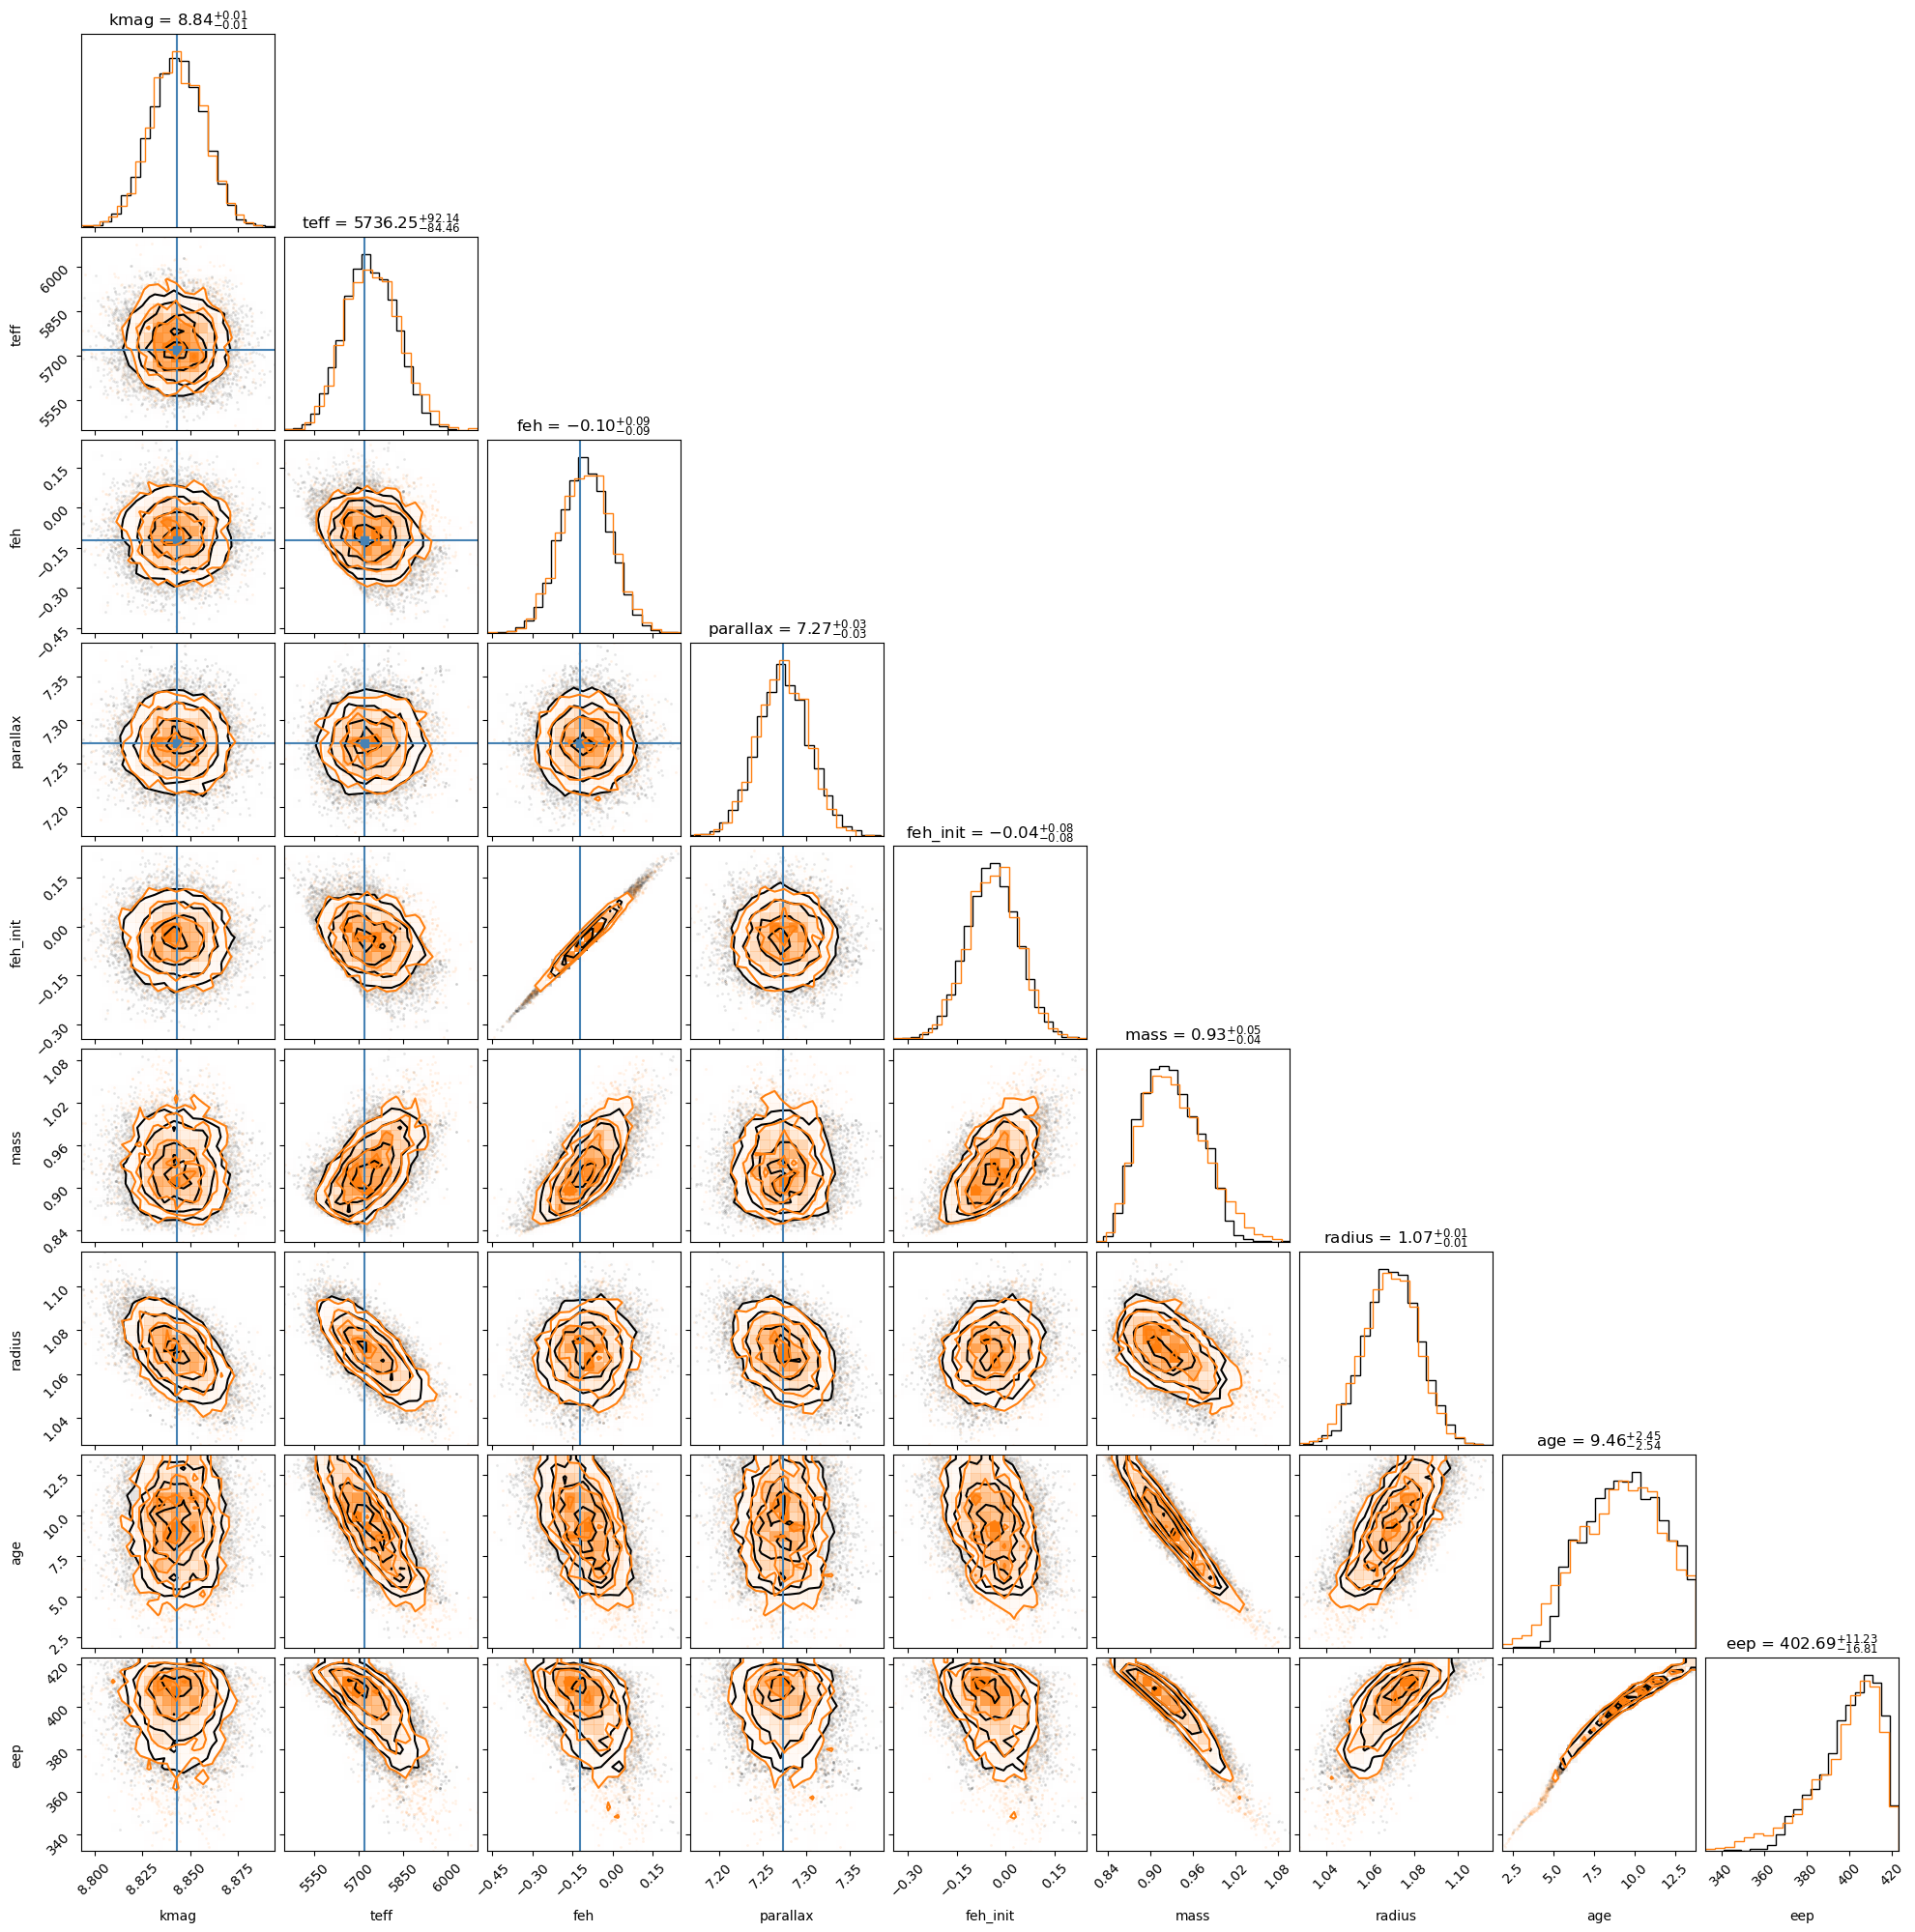

In [12]:
params = np.array(pd.DataFrame(data=dict(zip(outkeys, [samples_nuts[k] for k in outkeys]))))
fig = corner.corner(params, show_titles="%.2f", truths=obsvals, labels=outkeys, hist_kwargs={'density': True})
params = np.array(pd.DataFrame(data=dict(zip(outkeys, [samples_multinest[k] for k in outkeys]))))
_ = corner.corner(params, fig=fig, color='C1', hist_kwargs={'density': True})